In [1]:
import time
import h5py
import numpy as np
import tifffile
import tomopy
import matplotlib.pyplot as plt

from tomoDataClass import tomoData

PROJ_PATH  = '/Users/levihancock/Documents/Work/Code/TomoMono/alignedProjections/APSbeamtime_Oct25/cfg59_ds4x_aligned_20260505-121404.tif'
ANGLE_PATH = "/Users/levihancock/Library/CloudStorage/Box-Box/BYU_CXI_Research_Team/ProjectFolders/IFE-STAR/IFE-Ptycho-Tomo/APS_2ID_GUP1013052_August_2025/levi_tomoReconstructions/tomo_data_run_final_2.hdf5"


projs = tifffile.imread(PROJ_PATH).astype(np.float32)  # (n_angles, ny, nx)
with h5py.File(ANGLE_PATH) as f:
    angles = f['angles'][...] * np.pi / 180
    angles = angles - np.mean(angles)  # Shift angles to be centered around 0

print(f'Projections : {projs.shape}  [{projs.min():.3f}, {projs.max():.3f}]')
print(f'Angles      : {len(angles)}  [{np.degrees(angles.min()):.1f}°, {np.degrees(angles.max()):.1f}°]')

center = tomopy.find_center_vo(projs)
print(f'Rotation center: {center:.2f} px')

tomo = tomoData(projs, angles)

Projections : (558, 146, 327)  [-6.368, 0.541]
Angles      : 558  [-65.4°, 65.4°]
Rotation center: 163.25 px




Using CPU-based reconstruction. Algorithm:  gridrec
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Reconstruction completed.


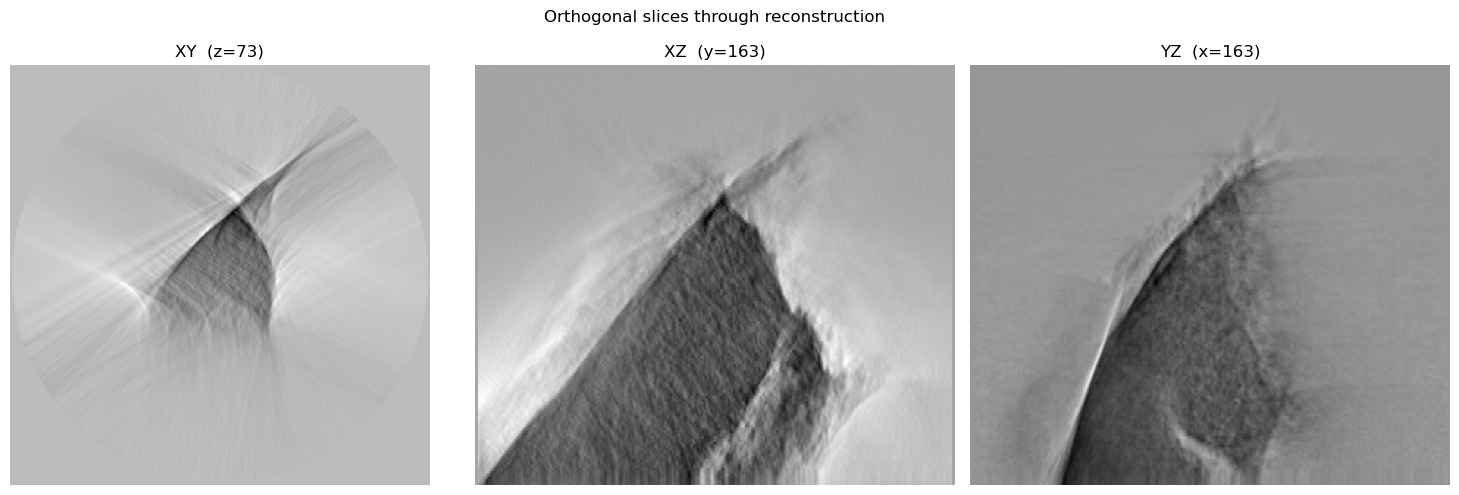

In [ ]:

tomo.reconstruct(algorithm='gridrec')
tomo.displayReconOrthogonalSlices()

In [4]:
tomo.makeNotebookReconMovie()

Output()

Applying Kovacik filter: 100%|██████████| 146/146 [00:02<00:00, 50.64it/s]


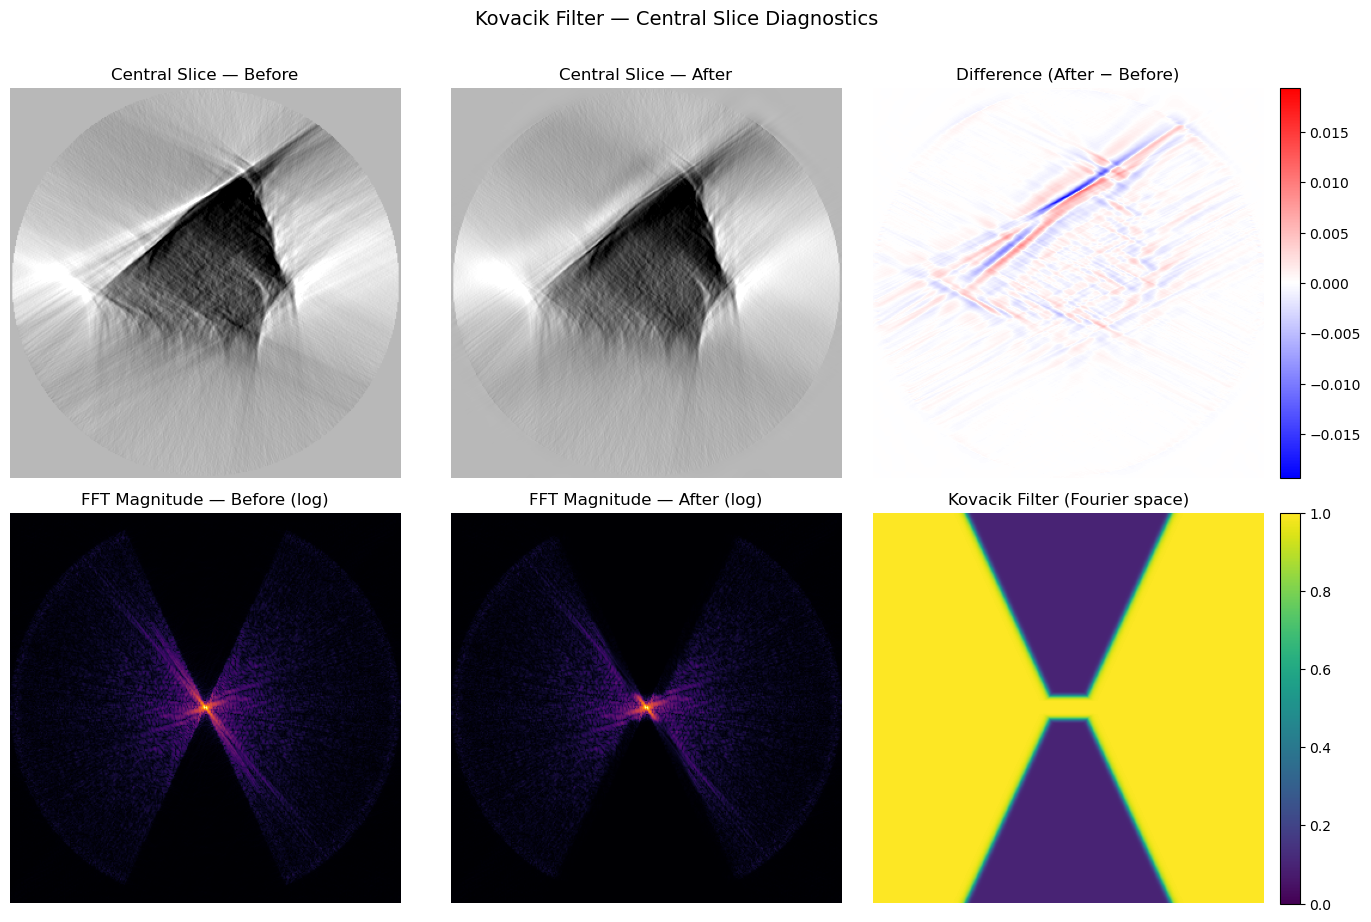

Kovacik filter applied.


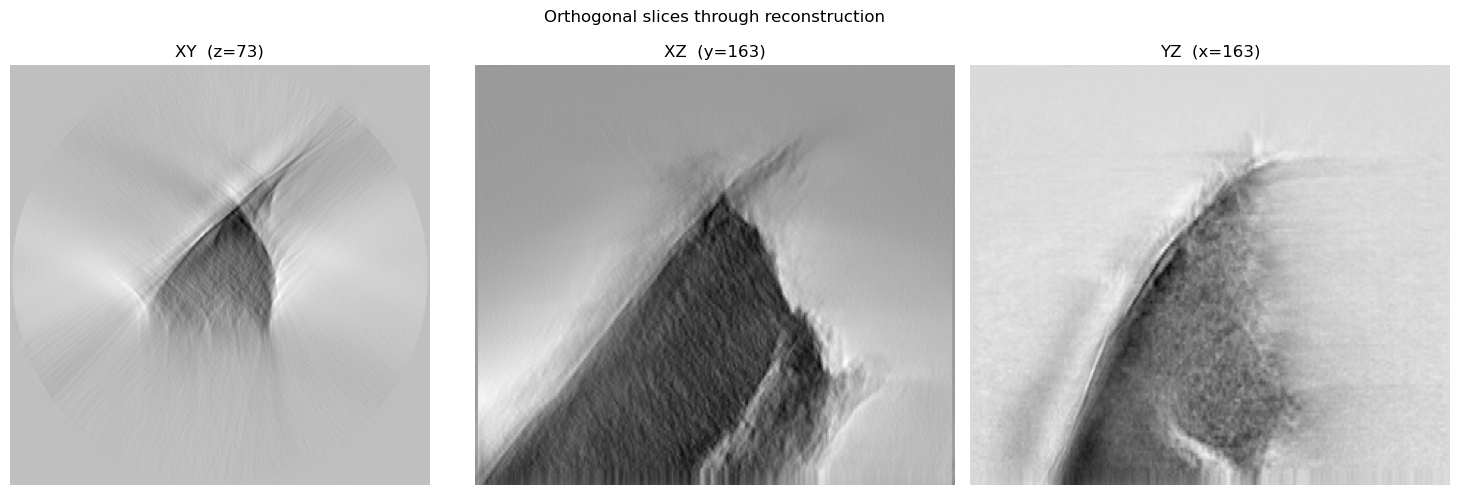

Output()

In [ ]:
tomo.kovacik_filter(
    mwr_length=10,             # tighten the ramp
    mwr_order=4,               # steep roll-off → stays near the boundary, preserves interior signal
    mwr_wmin=0.1,              # slightly less aggressive than 0.05
    cs_cutoff=10,               # keep
    cs_order=4,                # keep
    plot=True,
    plotSlice=96
)
tomo.displayReconOrthogonalSlices()
tomo.makeNotebookReconMovie()